In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df=sns.load_dataset("penguins")
print(df.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


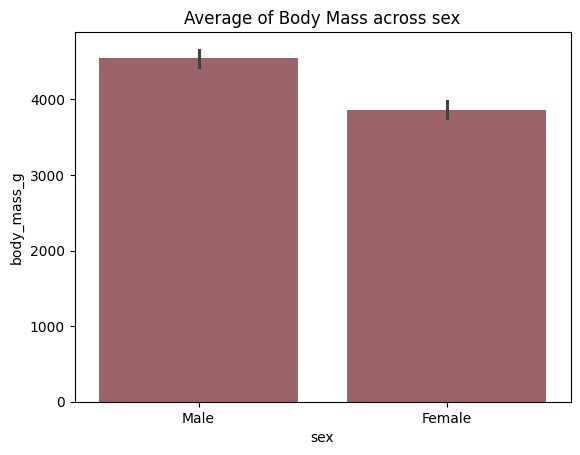

In [50]:
#Task #1

plt.title("Average of Body Mass across sex")

sns.barplot(x="sex", y="body_mass_g", data=df, color="#a65961")
plt.show()




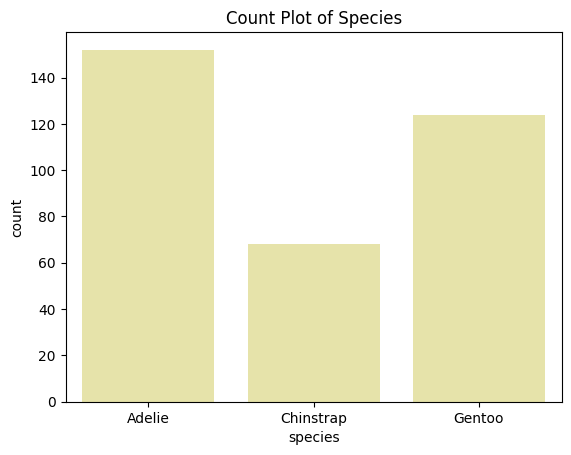

In [51]:
#TASK 2

plt.title("Count Plot of Species")

sns.countplot(data=df, x="species", color="#f0eca0")
plt.show()

Adelie has the majority of the counts as shown by the Count Plot

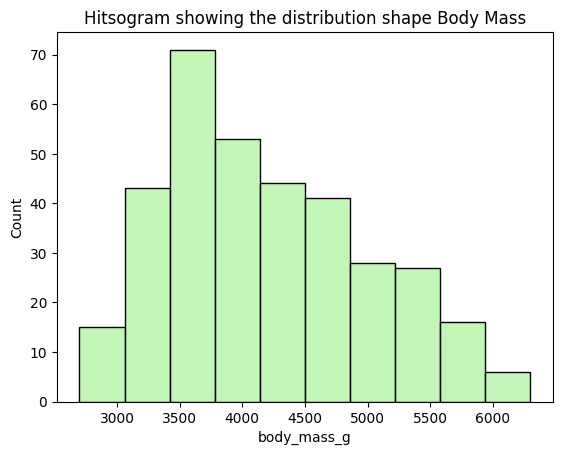

In [52]:
#TASK 3

plt.title("Hitsogram showing the distribution shape Body Mass")
sns.histplot(data=df, x="body_mass_g", bins=10, color="#acf39f")
plt.show()

The data of body mass is right skewed.

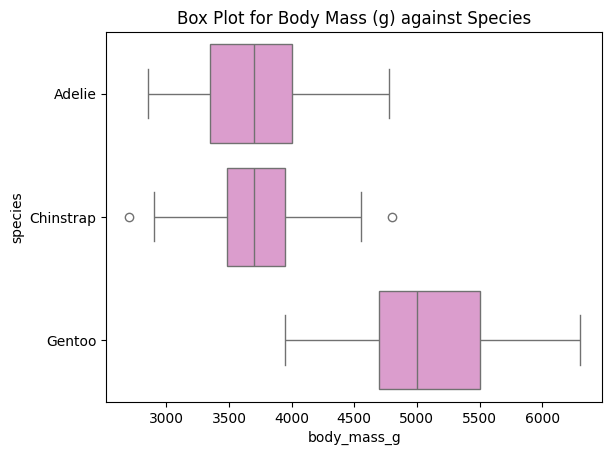

In [53]:
#TASK 4

plt.title("Box Plot for Body Mass (g) against Species")
sns.boxplot(data=df, x='body_mass_g', y="species", color="#e593d3")
plt.show()

There are 2 outliers for the species Chinstrap.

In [30]:
#TASK 5

Q1 = df['body_mass_g'].quantile(0.25)
Q3 = df['body_mass_g'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['body_mass_g']< lower)|(df['body_mass_g']>upper)]
print("Outliers:", len(outliers))

Outliers: 0


no, they do not match because above we found outliers specifically against the species and in the mathematical calculation, it is only done for the numeric column of body_mass_g.

In [26]:
df['body_mass_g']=df['body_mass_g'].fillna(df['body_mass_g'].mean())

In [45]:
#TASK 6

df['zscore'] = stats.zscore(df['body_mass_g'])
outliers_z = df[df['zscore'].abs() > 3]
print("Outliers:", len(outliers_z))

print(df['zscore'])

Outliers: 0
0     -0.565789
1     -0.503168
2     -1.192003
3      0.000000
4     -0.941517
         ...   
339    0.000000
340    0.811880
341    1.939064
342    1.250229
343    1.500715
Name: zscore, Length: 344, dtype: float64


The IQR and Z-score flags the same number of outliers (0).

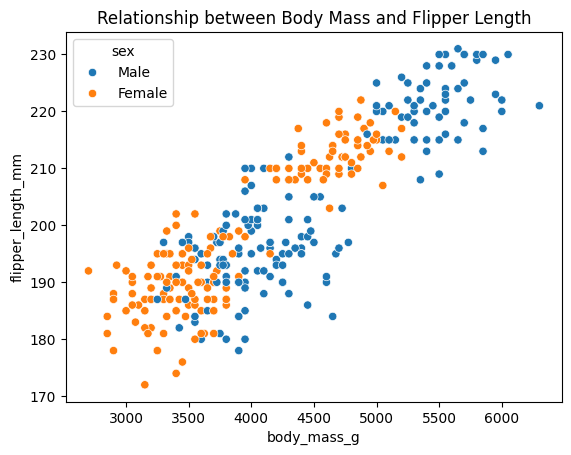

In [54]:
#TASK 7

plt.title("Relationship between Body Mass and Flipper Length")
sns.scatterplot(data=df, x="body_mass_g", y="flipper_length_mm", hue="sex")
plt.show()


There is a postive relationship between body mass and flipper length. as the body mass increases, the flipper length also increases. The colored graoh shows that female penguins are more likely to have smaller body mass and thus, smaller flipper length as compared to the male penguins.

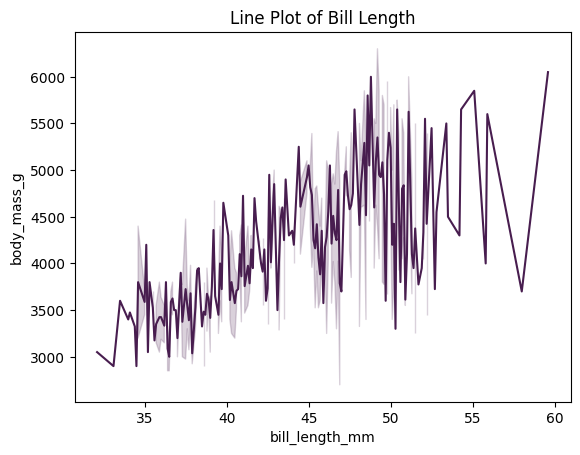

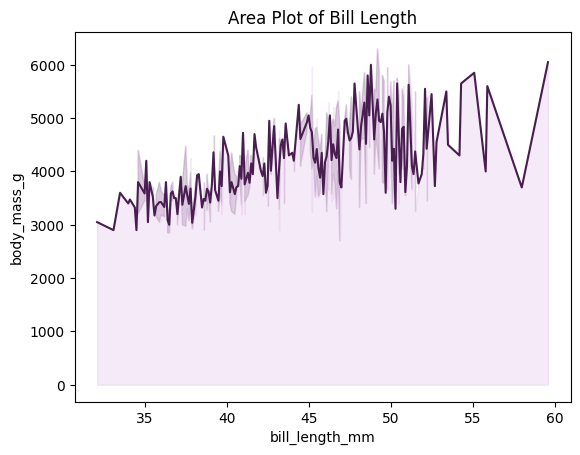

In [59]:
#Task 8
plt.title("Line Plot of Bill Length")
df_sorted = df.sort_values(by='bill_length_mm')
sns.lineplot(data=df_sorted, x='bill_length_mm', y="body_mass_g", color="#481d4f")

plt.show()

plt.title("Area Plot of Bill Length")
df_sorted = df.sort_values(by='bill_length_mm')
sns.lineplot(data=df_sorted, x='bill_length_mm', y="body_mass_g", color="#481d4f")
plt.fill_between(
    df_sorted["bill_length_mm"], df_sorted["body_mass_g"], alpha=0.3, color="#dfbae6"
)

plt.show()


Th area fill gives a string visual impression showing that the area is filled and all the data values are covered.

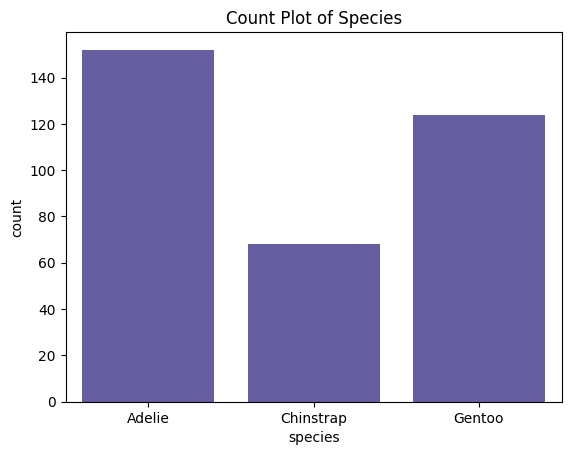

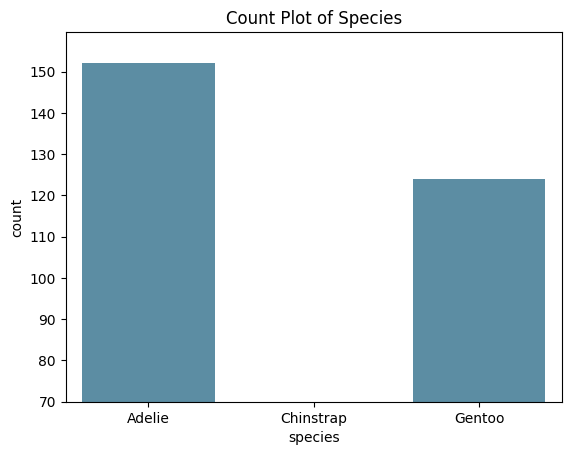

In [56]:
#TASK 9

plt.title("Count Plot of Species")

sns.countplot(data=df, x="species", color="#5c53ac")
plt.show()



plt.title("Count Plot of Species")

sns.countplot(data=df, x="species", color="#5091af")
plt.ylim(bottom=70)
plt.show()



Even though the data didn't change and we truncated the y-axis, setting the limit to min 70 then the bar of the Chinstrap is gone because it doesn't cover its count. This makes are data appear to be missing while it is not. therefore we must set the axes according to th given data to ensure a good visual representation.